# Background fields

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from operators.polynomials import SphericalHarmonicMode
from operators.worland_transform import WorlandTransform
from operators.associated_legendre_transform import AssociatedLegendreTransformSingleM
from fields import VectorFieldSingleM
from scipy import interpolate


c:\Users\gentle\Documents\Projects\MCmodes\operators\polynomials.py:247: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  """ compute spherical harmonics (excluding the e^{im\phi} term), evaluated on theta grid  """
c:\Users\gentle\Documents\Projects\MCmodes\operators\polynomials.py:275: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  """ compute value of C_l^m P_l^m(\cos\theta) / \sin\theta, on theta, for a single m
c:\Users\gentle\Documents\Projects\MCmodes\operators\polynomials.py:295: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  """ compute value of D_theta C_l^m P_l^m(\cos\theta), for a single m


Utilities

In [55]:
def plot_u_comp(xx, yy, ff, fig, gs, title=None, c_thresh=1e-7):
    ax = fig.add_subplot(gs)
    cmax = max([np.abs(np.real(ff)).max(), c_thresh])
    im = ax.pcolormesh(xx, yy, np.real(ff), 
        cmap='coolwarm', norm=mpl.colors.CenteredNorm(halfrange=cmax), shading='gouraud')
    plt.colorbar(im, ax=ax, orientation='horizontal')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(0, 1.01)
    ax.set_ylim(-1.01, +1.01)
    ax.axis('off')
    return ax

def plot_u_abs(xx, yy, ff, fig, gs, title=None, c_thresh=1e-7):
    ax = fig.add_subplot(gs)
    cmax = max([np.abs(np.real(ff)).max(), c_thresh])
    im = ax.pcolormesh(xx, yy, np.abs(np.real(ff)), 
        cmap='magma', vmin=0, vmax=cmax, shading='gouraud')
    plt.colorbar(im, ax=ax, orientation='horizontal')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(0, 1.01)
    ax.set_ylim(-1.01, +1.01)
    ax.axis('off')
    return ax

---
# List of fields

- S1

In [ ]:
B_bg_SH = [SphericalHarmonicMode("pol", 1, 0, "1/5 Sqrt[pi/3] r(5 - 3r^2)")]
B_bg_name = 'S1'

- S-L2N1

In [70]:
B_bg_SH = [SphericalHarmonicMode("pol", 2, 0, "1/4 Sqrt[3/26] r^2(5r^2 - 7)")]
B_bg_name = 'S-L2N1'

- S2

In [ ]:
B_bg_SH = [SphericalHarmonicMode("pol", 2, 0, "5/14 Sqrt[3/182] r^2(157 - 296r^2 + 143r^4)")]
B_bg_name = 'S2'

- T1

In [82]:
B_bg_SH = [SphericalHarmonicMode("tor", 1, 0, "3 Sqrt[pi] r(1 - r^2)"),]
B_bg_name = 'T1'

- T2

In [83]:
B_bg_SH = [SphericalHarmonicMode("tor", 2, 0, "(16/3) Sqrt[pi/5] r^2(1 - r^2)")]
B_bg_name = 'T2'

- T2-nbc

In [87]:
B_bg_SH = [SphericalHarmonicMode("tor", 2, 0, "(8/3) Sqrt[pi/5] r^4(3/2 - r^2)")]
B_bg_name = 'T2'

---
# Visualisation

In [88]:
nr, maxnl, m_val = 10, 3, 0
mode_bg = VectorFieldSingleM.from_SH_mode(nr, maxnl, B_bg_SH[0])
for mode_tmp in B_bg_SH[1:]:
    mode_bg = mode_bg + VectorFieldSingleM.from_SH_mode(nr, maxnl, mode_tmp)

rg = np.linspace(0, 1, 201)
tg = np.linspace(0, np.pi, 201)
rr, tt = np.meshgrid(rg, tg)
xx, zz = np.outer(np.sin(tg), rg), np.outer(np.cos(tg), rg)

jwp_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
lgd_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tg)

B_sph = mode_bg.physical_field(jwp_transform, lgd_transform).data
B_cyl = {
    's': B_sph['r']*np.sin(tt) + B_sph['theta']*np.cos(tt),
    'phi': B_sph['phi'],
    'z': B_sph['r']*np.cos(tt) - B_sph['theta']*np.sin(tt)
}

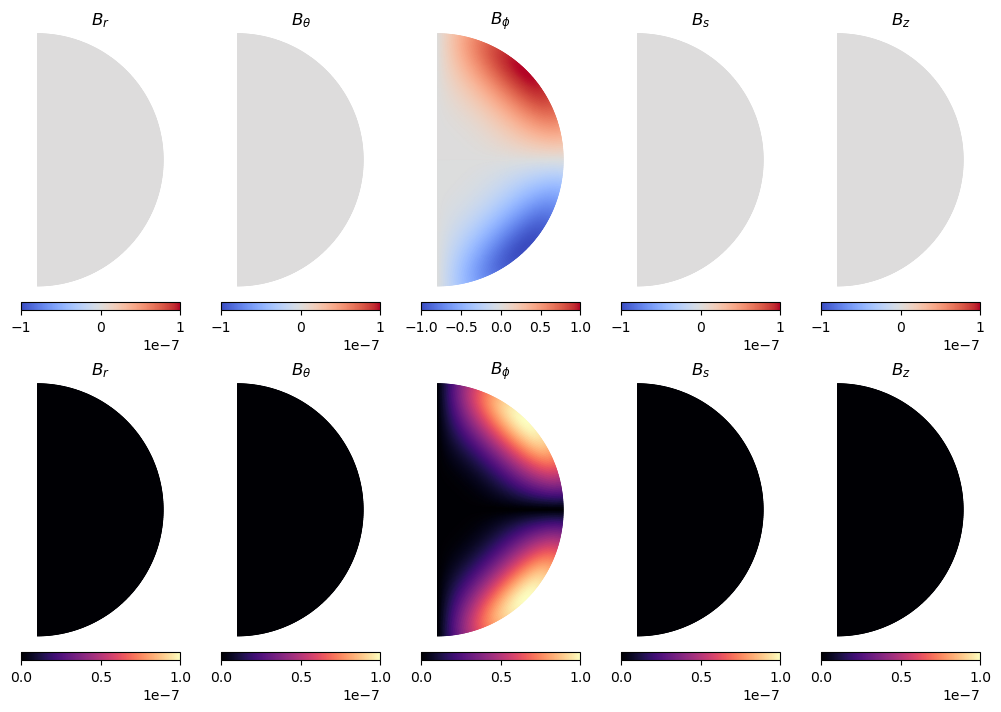

In [89]:
plot_fields = [B_sph['r'], B_sph['theta'], B_sph['phi'], B_cyl['s'], B_cyl['z']]
plot_fnames = [r'$B_r$', r'$B_\theta$', r'$B_\phi$', r'$B_s$', r'$B_z$']
force_lines = True

if force_lines:
    x_grid = np.linspace(0., 1., num=100)
    y_grid = np.linspace(-1., 1., num=200)
    xx_f, yy_f = np.meshgrid(x_grid, y_grid)
    Bx_grid = interpolate.griddata((xx.flatten(), zz.flatten()), np.real(B_cyl['s']).flatten(), (xx_f, yy_f))
    By_grid = interpolate.griddata((xx.flatten(), zz.flatten()), np.real(B_cyl['z']).flatten(), (xx_f, yy_f))

fig = plt.figure(figsize=(len(plot_fields)*2, 7), layout='constrained')
gs = fig.add_gridspec(2, len(plot_fields))

for ifield, field in enumerate(plot_fields):
    ax = plot_u_comp(xx, zz, field, fig, gs[0,ifield], title=plot_fnames[ifield])
    if force_lines:
        # ax.quiver(xx_f[::10, ::10], yy_f[::10, ::10], Bx_grid[::10, ::10], By_grid[::10, ::10], width=0.006, headlength=3)
        ax.streamplot(xx_f, yy_f, Bx_grid, By_grid, color='k', density=0.5, minlength=.5, linewidth=1)
    ax = plot_u_abs(xx, zz, field, fig, gs[1,ifield], title=plot_fnames[ifield])

plt.show()